# Twin Delayed DDPG (TD3)

**A hands-on tutorial with theory and PyTorch implementation**

---

DDPG worked, but anyone who used it knew it was unreliable: the same code with a different seed could succeed
brilliantly or fail completely. **TD3** ([Fujimoto, van Hoof & Meger, 2018](https://arxiv.org/abs/1802.09477))
diagnosed the cause — **over-estimation bias** in the critic, amplified by an actor that is explicitly trained to
exploit it — and fixed it with three small, well-motivated changes. The resulting algorithm was dramatically more
stable and outperformed every method of its time on the standard MuJoCo benchmarks. TD3 (together with SAC, published
the same year) became the default off-policy continuous-control baseline, and its tricks are now used far beyond it.

This notebook implements DDPG and TD3 in one code base with switches, so we can *measure* the over-estimation TD3
removes.

## What you will learn

1. Where **over-estimation bias** comes from in actor-critic methods, and why it compounds.
2. TD3's three fixes: **clipped double-Q learning**, **delayed policy updates**, **target policy smoothing**.
3. A **from-scratch PyTorch implementation** on `Pendulum-v1` that reduces to DDPG when the fixes are switched off.
4. A direct measurement of **estimated vs. true value** for both algorithms.
5. How TD3 relates to Double DQN, SAC and later methods.

## Notebook outline

1. Over-estimation in actor-critic methods
2. Fix 1: clipped double-Q learning
3. Fix 2: delayed policy updates
4. Fix 3: target policy smoothing
5. Implementation
6. Experiment: DDPG vs. TD3, and the over-estimation measurement
7. **Visual demonstration** of the trained agent
8. Strengths, weaknesses & connections
9. References

## 0. Setup

We use PyTorch for function approximation, `gymnasium` (the maintained fork of OpenAI Gym) for environments,
`pygame` for rendering frames, and `imageio` to turn rendered frames into GIFs. If you don't have these installed,
uncomment the install cell.

In [1]:
# !pip install torch gymnasium pygame imageio matplotlib numpy

In [2]:
import math
import random
import time
import warnings
from collections import deque
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="pkg_resources is deprecated")   # noisy pygame import warning

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}, gymnasium version: {gym.__version__}")

Using device: cpu
PyTorch version: 2.11.0, gymnasium version: 1.2.3


### Visualization helpers

Every tutorial in this folder ends with a *visual demonstration* of the trained agent. The three helpers below are
shared across notebooks:

- `record_episode` rolls out one episode with a given action function and collects rendered RGB frames.
- `show_filmstrip` shows a handful of evenly spaced frames as a static image (renders everywhere, including GitHub).
- `save_gif` writes an animated GIF to `media/` and displays it inline.

In [3]:
import os
import imageio.v3 as iio
from IPython.display import Image, display

MEDIA_DIR = "media"
os.makedirs(MEDIA_DIR, exist_ok=True)


def record_episode(env, act_fn, seed=0, max_steps=1000):
    """Roll out one episode in an env created with render_mode="rgb_array".

    `act_fn(obs) -> action`. Returns (frames, episode_return, episode_length).
    """
    obs, _ = env.reset(seed=seed)
    frames, ep_ret = [env.render()], 0.0
    for _ in range(max_steps):
        obs, reward, terminated, truncated, _ = env.step(act_fn(obs))
        ep_ret += reward
        frames.append(env.render())
        if terminated or truncated:
            break
    return frames, ep_ret, len(frames) - 1


def show_filmstrip(frames, n=8, title=None, captions=None):
    """Static preview: n evenly spaced frames side by side."""
    idx = np.linspace(0, len(frames) - 1, num=min(n, len(frames)), dtype=int)
    h, w = np.asarray(frames[0]).shape[:2]
    fw = 2.3
    fig, axes = plt.subplots(1, len(idx), figsize=(fw * len(idx), fw * h / w + 0.6))
    for ax, i in zip(np.atleast_1d(axes), idx):
        ax.imshow(frames[i])
        ax.axis("off")
        ax.set_title(captions[i] if captions is not None else f"t = {i}", fontsize=9)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def save_gif(frames, name, fps=30, max_frames=240, downscale=2):
    """Subsample/downscale frames, write media/<name>.gif and return an inline Image."""
    step = max(1, int(np.ceil(len(frames) / max_frames)))
    small = np.stack([np.asarray(f)[::downscale, ::downscale] for f in frames[::step]])
    path = os.path.join(MEDIA_DIR, f"{name}.gif")
    iio.imwrite(path, small, duration=int(1000 * step / fps), loop=0)
    print(f"Saved {path}  ({small.shape[0]} frames, {os.path.getsize(path) / 1e6:.2f} MB)")
    return Image(filename=path)

## 1. Over-Estimation in Actor-Critic Methods

Recall the DDPG critic target, $y = r + \gamma Q_{\phi^-}(s', \mu_{\theta^-}(s'))$. In Q-learning, over-estimation arises
because $\max_{a'}$ over noisy estimates is biased upward. In DDPG there is no explicit max — but the actor is
*trained* to maximize $Q_\phi$, so $\mu_\theta(s') \approx \arg\max_a Q_\phi(s', a)$, and the same bias appears through
the back door. Fujimoto et al. proved that even a single gradient step on the actor produces over-estimation in
expectation, then showed empirically that the critic's estimates in DDPG drift far above the true returns on MuJoCo
tasks.

Why does it matter? Two reasons:

1. **Bias accumulates through bootstrapping.** An over-estimate at $s'$ raises the target at $s$, which raises
   the estimate at $s$, which raises the target for its predecessors…
2. **The actor exploits it.** Wherever the critic has a spurious peak, the actor moves there — producing bad actions
   with high confidence — and the next batch of targets is computed at those very actions.

TD3's three modifications each attack one part of this loop.

## 2. Fix 1: Clipped Double-Q Learning

Double DQN decouples action *selection* from action *evaluation* using the online and target networks. Fujimoto et al.
found that in the actor-critic setting the two are too similar (the actor changes slowly) and the effect is weak. TD3
instead trains **two independent critics** $Q_{\phi_1}, Q_{\phi_2}$ and uses the **minimum** of their target
estimates:

$$
\boxed{\; y \;=\; r + \gamma\,(1-d)\; \min_{i = 1, 2}\, Q_{\phi_i^-}\big(s',\, \tilde a'\big) \;}
$$

Taking the minimum biases the target *downward* — an **under**-estimate — but under-estimation is far less harmful:
it does not propagate through the actor (the actor won't seek out states whose value is under-estimated). Both critics
are regressed onto the same target $y$; the actor is updated using $Q_{\phi_1}$ only.

## 3. Fix 2: Delayed Policy Updates

The actor should be trained against an *accurate* critic. If the critic's estimate is currently wrong (it changes every
step), the actor will follow the error. TD3 updates the actor (and the target networks) only every $d$ critic updates
($d = 2$ in the paper):

- the critic gets $d$ steps to reduce its error before the policy moves,
- the target networks (and therefore the targets) change less often, reducing the variance of the value estimate,
- the actor is updated with a less-biased critic, which cuts the feedback loop.

## 4. Fix 3: Target Policy Smoothing

A deterministic actor can over-fit to narrow peaks in the critic: if $Q_\phi(s', \cdot)$ has a sharp spike at some action,
the actor moves there and the target inherits the spike. TD3 regularizes the target by **adding clipped noise to the
target action**:

$$
\tilde a' \;=\; \operatorname{clip}\!\big(\mu_{\theta^-}(s') + \epsilon,\; a_{\min},\; a_{\max}\big), \qquad
\epsilon \sim \operatorname{clip}\big(\mathcal{N}(0, \sigma^2),\, -c,\, c\big).
$$

Averaged over the minibatch, this smooths the value estimate over a small neighborhood of the target action — an
implicit statement that similar actions should have similar values (like SARSA's expected value under a noisy policy).
Typical values: $\sigma = 0.2$, $c = 0.5$ (in units of the normalized action range).

### The TD3 algorithm

1. Act with Gaussian exploration noise; store the transition in $\mathcal{D}$.
2. Sample a minibatch; compute the smoothed target action $\tilde a'$ and the clipped double-Q target $y$.
3. Update both critics by regression on $y$.
4. Every $d$ steps: update the actor by ascending $Q_{\phi_1}(s, \mu_\theta(s))$; soft-update all three target networks.

## 5. Implementation

### 5.1 Hyperparameters

The three fixes are switches. With `twin_critics=False`, `policy_delay=1`, `target_noise=0.0` the algorithm is exactly DDPG.

In [4]:
@dataclass
class TD3Config:
    env_id: str = "Pendulum-v1"
    total_timesteps: int = 25_000
    learning_starts: int = 2_000
    buffer_size: int = 100_000
    batch_size: int = 256
    gamma: float = 0.99
    tau: float = 0.005
    actor_lr: float = 1e-3
    critic_lr: float = 1e-3
    hidden: int = 256
    expl_noise: float = 0.1       # exploration noise std (normalized action units)
    # --- the three TD3 ingredients ---
    twin_critics: bool = True     # fix 1: clipped double-Q
    policy_delay: int = 2         # fix 2: delayed actor / target updates
    target_noise: float = 0.2     # fix 3: target policy smoothing std (0 disables)
    target_noise_clip: float = 0.5
    eval_interval: int = 1_000
    eval_episodes: int = 5


def ddpg_config(**kw):
    return TD3Config(twin_critics=False, policy_delay=1, target_noise=0.0, **kw)

print(TD3Config())

TD3Config(env_id='Pendulum-v1', total_timesteps=25000, learning_starts=2000, buffer_size=100000, batch_size=256, gamma=0.99, tau=0.005, actor_lr=0.001, critic_lr=0.001, hidden=256, expl_noise=0.1, twin_critics=True, policy_delay=2, target_noise=0.2, target_noise_clip=0.5, eval_interval=1000, eval_episodes=5)


### 5.2 Networks and replay buffer

Same as DDPG, except the critic module holds **two** Q-networks.

In [5]:
class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, act_limit, hidden=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, act_dim), nn.Tanh())
        self.act_limit = act_limit
    def forward(self, obs):
        return self.act_limit * self.net(obs)


class TwinCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        make = lambda: nn.Sequential(nn.Linear(obs_dim + act_dim, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 1))
        self.q1, self.q2 = make(), make()
    def forward(self, obs, act):
        x = torch.cat([obs, act], -1)
        return self.q1(x).squeeze(-1), self.q2(x).squeeze(-1)
    def Q1(self, obs, act):
        return self.q1(torch.cat([obs, act], -1)).squeeze(-1)


class ReplayBuffer:
    def __init__(self, capacity, obs_dim, act_dim):
        self.capacity, self.ptr, self.size = capacity, 0, 0
        self.obs = np.zeros((capacity, obs_dim), np.float32); self.next_obs = np.zeros((capacity, obs_dim), np.float32)
        self.act = np.zeros((capacity, act_dim), np.float32); self.rew = np.zeros(capacity, np.float32); self.done = np.zeros(capacity, np.float32)
    def add(self, o, a, r, o2, d):
        i = self.ptr; self.obs[i], self.act[i], self.rew[i], self.next_obs[i], self.done[i] = o, a, r, o2, d
        self.ptr = (self.ptr + 1) % self.capacity; self.size = min(self.size + 1, self.capacity)
    def sample(self, n):
        idx = np.random.randint(0, self.size, n); f = lambda x: torch.as_tensor(x[idx], device=device)
        return f(self.obs), f(self.act), f(self.rew), f(self.next_obs), f(self.done)


def soft_update(target, source, tau):
    with torch.no_grad():
        for p_t, p in zip(target.parameters(), source.parameters()):
            p_t.mul_(1 - tau).add_(tau * p)

### 5.3 The TD3 update

Read the three fixes off the code: `target_noise` (smoothing), `torch.min` (clipped double-Q), `policy_delay` (delayed updates).

In [6]:
def td3_update(actor, critic, actor_targ, critic_targ, actor_opt, critic_opt, batch, cfg, step, act_limit):
    obs, act, rew, next_obs, done = batch

    with torch.no_grad():
        next_act = actor_targ(next_obs)
        if cfg.target_noise > 0:                                     # fix 3: target policy smoothing
            noise = (torch.randn_like(next_act) * cfg.target_noise * act_limit).clamp(-cfg.target_noise_clip * act_limit, cfg.target_noise_clip * act_limit)
            next_act = (next_act + noise).clamp(-act_limit, act_limit)
        q1_t, q2_t = critic_targ(next_obs, next_act)
        next_q = torch.min(q1_t, q2_t) if cfg.twin_critics else q1_t   # fix 1: clipped double-Q
        target = rew + cfg.gamma * (1 - done) * next_q

    q1, q2 = critic(obs, act)
    critic_loss = F.mse_loss(q1, target) + (F.mse_loss(q2, target) if cfg.twin_critics else 0.0)
    critic_opt.zero_grad(); critic_loss.backward(); critic_opt.step()

    actor_loss = None
    if step % cfg.policy_delay == 0:                                 # fix 2: delayed policy + target updates
        actor_loss = -critic.Q1(obs, actor(obs)).mean()
        actor_opt.zero_grad(); actor_loss.backward(); actor_opt.step()
        soft_update(critic_targ, critic, cfg.tau); soft_update(actor_targ, actor, cfg.tau)
    return critic_loss.item(), (None if actor_loss is None else -actor_loss.item())

### 5.4 Training loop with value-estimate tracking

To *measure* over-estimation we do what the TD3 paper did: periodically take states from the buffer, record the
critic's estimate $Q_{\phi_1}(s, \mu(s))$, and compare it with the **true discounted return** obtained by actually
rolling out the current policy from those states. Pendulum lets us reset the environment to an arbitrary state by
setting `env.unwrapped.state`, which makes this cheap.

In [7]:
def evaluate(actor, env_id, n_episodes=5, seed=10_000):
    env = gym.make(env_id); rets = []
    for i in range(n_episodes):
        o, _ = env.reset(seed=seed + i); done, R = False, 0.0
        while not done:
            with torch.no_grad():
                a = actor(torch.as_tensor(o, dtype=torch.float32, device=device)).cpu().numpy()
            o, r, term, trunc, _ = env.step(a); R += r; done = term or trunc
        rets.append(R)
    env.close(); return float(np.mean(rets))


def true_discounted_return(actor, env_id, obs, gamma, horizon=200):
    """Roll out the deterministic policy from the pendulum state encoded in `obs` (cos, sin, thetadot)."""
    env = gym.make(env_id); env.reset(seed=0)
    env.unwrapped.state = np.array([np.arctan2(obs[1], obs[0]), obs[2]], dtype=np.float64)
    o, G, disc = env.unwrapped._get_obs(), 0.0, 1.0
    for _ in range(horizon):
        with torch.no_grad():
            a = actor(torch.as_tensor(o, dtype=torch.float32, device=device)).cpu().numpy()
        o, r, term, trunc, _ = env.step(a); G += disc * r; disc *= gamma
        if term: break
    env.close(); return G


def train(cfg: TD3Config, seed=SEED, verbose=True, name="TD3"):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env = gym.make(cfg.env_id); env = gym.wrappers.RecordEpisodeStatistics(env)
    obs_dim, act_dim, act_limit = env.observation_space.shape[0], env.action_space.shape[0], float(env.action_space.high[0])
    actor, critic = Actor(obs_dim, act_dim, act_limit, cfg.hidden).to(device), TwinCritic(obs_dim, act_dim, cfg.hidden).to(device)
    actor_targ, critic_targ = Actor(obs_dim, act_dim, act_limit, cfg.hidden).to(device), TwinCritic(obs_dim, act_dim, cfg.hidden).to(device)
    actor_targ.load_state_dict(actor.state_dict()); critic_targ.load_state_dict(critic.state_dict())
    actor_opt, critic_opt = torch.optim.Adam(actor.parameters(), lr=cfg.actor_lr), torch.optim.Adam(critic.parameters(), lr=cfg.critic_lr)
    buffer = ReplayBuffer(cfg.buffer_size, obs_dim, act_dim)
    rng = np.random.default_rng(seed)

    logs = dict(train_returns=[], train_steps=[], eval_steps=[], eval_returns=[], est_steps=[], q_est=[], q_true=[])
    best_ret, best_state = -np.inf, None
    o, _ = env.reset(seed=seed); env.action_space.seed(seed)
    for step in range(1, cfg.total_timesteps + 1):
        if step <= cfg.learning_starts:
            a = env.action_space.sample()
        else:
            with torch.no_grad():
                a = actor(torch.as_tensor(o, dtype=torch.float32, device=device)).cpu().numpy()
            a = np.clip(a + rng.normal(0, cfg.expl_noise * act_limit, act_dim), -act_limit, act_limit).astype(np.float32)
        o2, r, term, trunc, info = env.step(a)
        buffer.add(o, a, r, o2, float(term)); o = o2
        if term or trunc:
            logs["train_returns"].append(float(info["episode"]["r"])); logs["train_steps"].append(step); o, _ = env.reset()

        if step > cfg.learning_starts:
            td3_update(actor, critic, actor_targ, critic_targ, actor_opt, critic_opt, buffer.sample(cfg.batch_size), cfg, step, act_limit)

        if step % cfg.eval_interval == 0:
            ret = evaluate(actor, cfg.env_id, cfg.eval_episodes)
            logs["eval_steps"].append(step); logs["eval_returns"].append(ret)
            if ret >= best_ret:
                best_ret, best_state = ret, {k: v.clone() for k, v in actor.state_dict().items()}
            # estimated vs. true value on 10 states from the buffer
            if step > cfg.learning_starts:
                idx = rng.integers(0, buffer.size, 10); s_batch = torch.as_tensor(buffer.obs[idx], device=device)
                with torch.no_grad():
                    q_est = critic.Q1(s_batch, actor(s_batch)).mean().item()
                q_true = float(np.mean([true_discounted_return(actor, cfg.env_id, buffer.obs[i], cfg.gamma) for i in idx]))
                logs["est_steps"].append(step); logs["q_est"].append(q_est); logs["q_true"].append(q_true)
                if verbose:
                    print(f"[{name}] step {step:6d} | eval return {ret:8.1f} | Q estimate {q_est:8.1f} | true return {q_true:8.1f}")
    env.close()
    best_actor = Actor(obs_dim, act_dim, act_limit, cfg.hidden).to(device); best_actor.load_state_dict(best_state)
    return actor, best_actor, critic, logs

## 6. Experiment: DDPG vs. TD3

Same seed, same networks, same hyperparameters — only the three switches differ.

In [8]:
runs = {}
for name, cfg in [("DDPG", ddpg_config()), ("TD3", TD3Config())]:
    print(f"===== {name} =====")
    t0 = time.time()
    runs[name] = dict(zip(["actor", "best_actor", "critic", "logs"], train(cfg, verbose=True, name=name)))
    print(f"{name}: {time.time() - t0:.0f}s, best eval return {max(runs[name]['logs']['eval_returns']):.1f}\n")

===== DDPG =====


[DDPG] step   3000 | eval return  -1403.0 | Q estimate    -28.8 | true return   -612.3


[DDPG] step   4000 | eval return   -856.1 | Q estimate    -54.6 | true return   -427.7


[DDPG] step   5000 | eval return   -288.9 | Q estimate    -56.3 | true return   -164.7


[DDPG] step   6000 | eval return   -100.9 | Q estimate    -69.1 | true return   -140.4


...

[TD3] step  21000 | eval return    -98.6 | Q estimate    -27.3 | true return    -23.0


[TD3] step  22000 | eval return    -98.6 | Q estimate    -52.8 | true return    -50.4


[TD3] step  23000 | eval return    -98.6 | Q estimate    -52.6 | true return    -47.8


[TD3] step  24000 | eval return    -98.1 | Q estimate    -41.3 | true return    -38.3


[TD3] step  25000 | eval return    -98.3 | Q estimate    -40.5 | true return    -40.0
TD3: 39s, best eval return -96.9



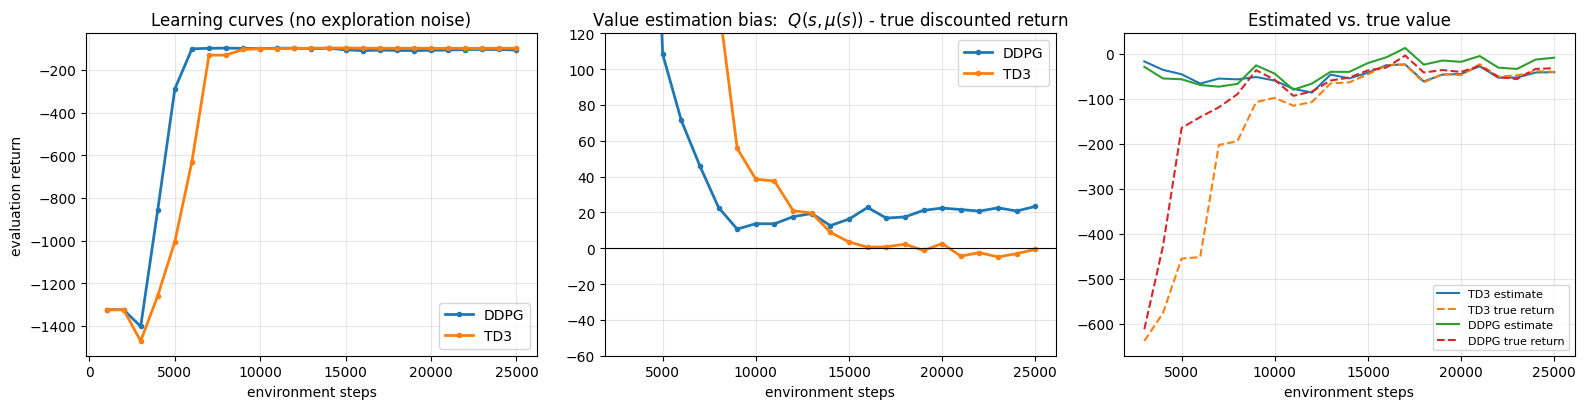

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for name, run in runs.items():
    L = run["logs"]
    axes[0].plot(L["eval_steps"], L["eval_returns"], "o-", lw=2, ms=3, label=name)
    axes[1].plot(L["est_steps"], np.array(L["q_est"]) - np.array(L["q_true"]), "o-", lw=2, ms=3, label=name)
axes[0].set_xlabel("environment steps"); axes[0].set_ylabel("evaluation return"); axes[0].set_title("Learning curves (no exploration noise)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].axhline(0, color="black", lw=0.8); axes[1].set_ylim(-60, 120); axes[1].set_xlabel("environment steps"); axes[1].set_title("Value estimation bias:  $Q(s,\\mu(s))$ - true discounted return")
axes[1].legend(); axes[1].grid(alpha=0.3)
L = runs["TD3"]["logs"]
axes[2].plot(L["est_steps"], L["q_est"], label="TD3 estimate"); axes[2].plot(L["est_steps"], L["q_true"], "--", label="TD3 true return")
L = runs["DDPG"]["logs"]
axes[2].plot(L["est_steps"], L["q_est"], label="DDPG estimate"); axes[2].plot(L["est_steps"], L["q_true"], "--", label="DDPG true return")
axes[2].set_xlabel("environment steps"); axes[2].set_title("Estimated vs. true value"); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the plots.** Pendulum is easy enough that both algorithms solve it, but the *value estimates* differ: once
training has settled, DDPG's critic sits above the true return (a persistent positive bias in the middle panel), while
TD3's clipped double-Q target keeps the estimate at or slightly *below* the truth. (In the first few thousand steps
both critics are wildly optimistic simply because they have not learned yet — that part is off the scale of the middle
panel.) On harder tasks (Hopper, Walker, Ant) this difference is the difference between learning and diverging.

### 6.1 Ablation: which of the three fixes matters?

The TD3 paper's ablation found that clipped double-Q contributes the most and that removing any single component hurts.
The switches in `TD3Config` make it easy to repeat that study — try `TD3Config(twin_critics=False)` or
`TD3Config(target_noise=0.0)` and compare.

## 7. Visual Demonstration

TD3 best actor, 10 fresh evaluation episodes: -108.1


Returns of 5 recorded episodes (different start angles): [-124, -1, -116, -224, -236]; showing the median one (-123.8)


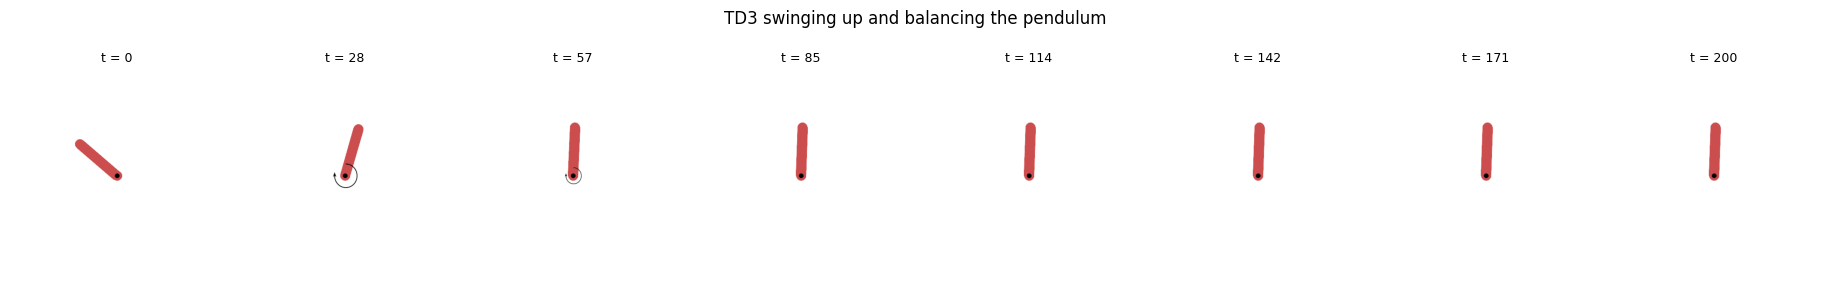

In [10]:
best_actor = runs["TD3"]["best_actor"]
def act_det(obs):
    with torch.no_grad():
        return best_actor(torch.as_tensor(obs, dtype=torch.float32, device=device)).cpu().numpy()

print(f"TD3 best actor, 10 fresh evaluation episodes: {evaluate(best_actor, 'Pendulum-v1', 10, seed=555):.1f}")
render_env = gym.make("Pendulum-v1", render_mode="rgb_array")
episodes = [record_episode(render_env, act_det, seed=s, max_steps=200) for s in range(5)]
render_env.close()
frames, ep_ret, ep_len = sorted(episodes, key=lambda e: e[1])[len(episodes) // 2]   # the median-return episode of 5
print(f"Returns of 5 recorded episodes (different start angles): {[round(e[1]) for e in episodes]}; showing the median one ({ep_ret:.1f})")
show_filmstrip(frames, n=8, title="TD3 swinging up and balancing the pendulum")

Saved media/td3_pendulum.gif  (201 frames, 0.08 MB)


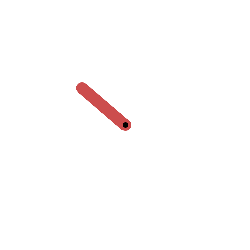

In [11]:
save_gif(frames, "td3_pendulum", fps=25)

## 8. Strengths, Weaknesses & Connections

### Strengths

- **Stability.** TD3 turned DDPG from a lottery into a reliable baseline; its three fixes are cheap and now standard
  (twin critics appear in SAC, REDQ, DrQ-v2, TD-MPC, …).
- **Sample efficiency** of off-policy learning with a deterministic, low-variance actor gradient.
- **Simplicity relative to its gains**: ~20 extra lines over DDPG.

### Weaknesses

- **Deterministic policy, naive exploration.** Still relies on additive Gaussian noise; struggles with sparse rewards
  or tasks needing multi-modal behavior.
- **Under-estimation** can be pessimistic in the wrong places; the minimum over two critics is a crude (if effective)
  uncertainty estimate. Later methods (REDQ, TQC) use ensembles or quantiles to tune the pessimism.
- **Hyperparameters** (delay, noise scales) still matter, though far less than in DDPG.

### Connections

- **Double Q-learning / Double DQN**: the idea of decoupling selection from evaluation, which TD3 sharpened into the
  minimum over two critics.
- **SAC** (next notebook), published concurrently: also uses twin critics, but replaces the deterministic actor with a
  maximum-entropy stochastic policy — the two are the standard continuous-control baselines to this day.
- **TD3+BC** (Fujimoto & Gu, 2021): TD3 with a behavior-cloning term became a strong, minimal *offline* RL baseline.
- **DrQ-v2** (image-based control) is TD3 with data augmentation and $n$-step returns; **TD-MPC2** uses TD3-style
  value learning inside a model-based planner.

## 9. References

1. **Fujimoto, S., van Hoof, H., & Meger, D.** (2018). *Addressing function approximation error in actor-critic methods.* ICML. [[pdf]](https://arxiv.org/abs/1802.09477)
2. **Lillicrap, T. P., et al.** (2016). *Continuous control with deep reinforcement learning.* ICLR (DDPG).
3. **van Hasselt, H., Guez, A., & Silver, D.** (2016). *Deep reinforcement learning with Double Q-learning.* AAAI.
4. **Thrun, S., & Schwartz, A.** (1993). *Issues in using function approximation for reinforcement learning.* Connectionist Models Summer School.
5. **Haarnoja, T., et al.** (2018). *Soft actor-critic.* ICML.
6. **Chen, X., Wang, C., Zhou, Z., & Ross, K.** (2021). *Randomized ensembled double Q-learning: Learning fast without a model.* ICLR (REDQ).
7. **Fujimoto, S., & Gu, S. S.** (2021). *A minimalist approach to offline reinforcement learning.* NeurIPS (TD3+BC).
8. **Yarats, D., Fergus, R., Lazaric, A., & Pinto, L.** (2022). *Mastering visual continuous control: Improved data-augmented reinforcement learning.* ICLR (DrQ-v2).